# UAS Bengkel Koding Data Science
## Project: Customer Churn Prediction

Dataset yang digunakan adalah Sales and Marketing Customer Dataset.

Target prediksi:
- `churn = 0` berarti pelanggan tidak churn
- `churn = 1` berarti pelanggan churn

Notebook ini mengerjakan bagian:
## Poin Penugasan 1 — EDA

In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

import warnings
warnings.filterwarnings("ignore")

# Setting tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

## Menghubungkan Google Colab dengan Google Drive

Dataset disimpan di Google Drive, sehingga langkah pertama adalah melakukan mount Drive.

In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Mounted at /content/drive



## Load Dataset

Silakan sesuaikan `DATA_PATH` dengan lokasi file dataset di Google Drive.

Contoh:
- `/content/drive/MyDrive/dataset/sales_and_marketing.csv`
- `/content/drive/MyDrive/UAS/sales_marketing.csv`
> Tambahkan blockquote



In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

# GANTI PATH INI SESUAI LOKASI DATASET KAMU DI GOOGLE DRIVE
DATA_PATH = "/content/drive/MyDrive/UAS_BENGKOD/sales_and_marketing.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dimuat.")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat.
Jumlah baris: 15000
Jumlah kolom: 30


## Pemeriksaan Awal Dataset

Pada tahap ini dilakukan pengecekan awal struktur dataset, seperti ukuran data, nama kolom, dan tipe data awal.

In [ ]:
# ============================================================
# PEMERIKSAAN AWAL DATASET
# ============================================================

print("Ukuran dataset:")
display(df.shape)

print("\nDaftar kolom:")
display(df.columns.tolist())

print("\nTipe data setiap kolom:")
display(df.dtypes)

Ukuran dataset:


(15000, 30)


Daftar kolom:


['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'signup_date',
 'last_purchase_date',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'coupon_code',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn']


Tipe data setiap kolom:


,0
customer_id,int64
gender,object
age,float64
country,object
city,object
signup_date,object
last_purchase_date,object
acquisition_channel,object
device_type,object
subscription_type,object


## Standarisasi Nama Kolom

Nama kolom dibuat lowercase dan spasi diganti underscore agar lebih mudah digunakan dalam proses analisis dan modeling.

# ============================================================
# STANDARISASI NAMA KOLOM
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Nama kolom setelah distandarisasi:")
display(df.columns.tolist())

In [ ]:
# ============================================================
# STANDARISASI NAMA KOLOM
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Nama kolom setelah distandarisasi:")
display(df.columns.tolist())

Nama kolom setelah distandarisasi:


['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'signup_date',
 'last_purchase_date',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'coupon_code',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn']

## Konversi Kolom Tanggal

Kolom `signup_date` dan `last_purchase_date` dikonversi menjadi format datetime apabila kolom tersebut tersedia di dataset.

In [ ]:
# ============================================================
# KONVERSI KOLOM TANGGAL
# ============================================================

date_columns = ["signup_date", "last_purchase_date"]

converted_cols = []

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        converted_cols.append(col)

print("Kolom tanggal yang berhasil dikonversi:")
display(converted_cols)

print("\nTipe data setelah konversi:")
if len(converted_cols) > 0:
    display(df[converted_cols].dtypes)
else:
    print("Tidak ada kolom tanggal yang ditemukan.")

Kolom tanggal yang berhasil dikonversi:


['signup_date', 'last_purchase_date']


Tipe data setelah konversi:


,0
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]


# Poin Penugasan 1.1 — Menampilkan 5 Baris Pertama Dataset

Bagian ini digunakan untuk melihat contoh isi data pada 5 baris pertama.

In [ ]:
# ============================================================
# POIN 1.1 - MENAMPILKAN 5 BARIS PERTAMA DATASET
# ============================================================

display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10,2024-12-31,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,NEW20,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,NEW20,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23,2024-04-28,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,NaN,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,NaN,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,NaN,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


# Poin Penugasan 1.1 — Menampilkan Informasi Dataset

Bagian ini digunakan untuk melihat jumlah data, tipe data setiap kolom, dan jumlah nilai non-null.

In [ ]:
# ============================================================
# POIN 1.1 - INFORMASI DATASET
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 15000 non-null  int64         
 1   gender                      14262 non-null  object        
 2   age                         13800 non-null  float64       
 3   country                     15000 non-null  object        
 4   city                        15000 non-null  object        
 5   signup_date                 15000 non-null  datetime64[ns]
 6   last_purchase_date          15000 non-null  datetime64[ns]
 7   acquisition_channel         15000 non-null  object        
 8   device_type                 15000 non-null  object        
 9   subscription_type           15000 non-null  object        
 10  is_premium_user             15000 non-null  int64         
 11  total_visits                15000 non-null  int64     

# Poin Penugasan 1.1 — Statistik Deskriptif

Bagian ini menampilkan statistik deskriptif untuk kolom numerik dan kategorikal.

In [ ]:
# ============================================================
# POIN 1.1 - STATISTIK DESKRIPTIF KOLOM NUMERIK
# ============================================================

display(df.describe())

,customer_id,age,signup_date,last_purchase_date,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,2023-05-15 21:46:04.800000,2024-02-04 16:45:18.720000256,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
min,10001.000000,-4.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,2022-09-04 00:00:00,2023-07-17 00:00:00,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,2023-05-19 00:00:00,2024-02-07 00:00:00,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,2024-01-22 00:00:00,2024-08-25 00:00:00,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,2024-09-26 00:00:00,2025-03-10 00:00:00,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000
std,4330.271354,10.334384,NaN,NaN,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192


In [ ]:
# ============================================================
# POIN 1.1 - STATISTIK DESKRIPTIF SEMUA KOLOM
# ============================================================

display(df.describe(include="all"))

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,8867,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,NaN,NaN,5,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,NaN,NaN,Organic,Tablet,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,REF10,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,NaN,NaN,3055,5043,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2995,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,2023-05-15 21:46:04.800000,2024-02-04 16:45:18.720000256,NaN,NaN,NaN,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,NaN,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
min,10001.000000,NaN,-4.000000,NaN,NaN,2022-01-01 00:00:00,2023-01-01 00:00:00,NaN,NaN,NaN,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,2022-09-04 00:00:00,2023-07-17 00:00:00,NaN,NaN,NaN,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,NaN,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,2023-05-19 00:00:00,2024-02-07 00:00:00,NaN,NaN,NaN,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,NaN,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,2024-01-22 00:00:00,2024-08-25 00:00:00,NaN,NaN,NaN,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,NaN,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,NaN,95.000000,NaN,NaN,2024-09-26 00:00:00,2025-03-10 00:00:00,NaN,NaN,NaN,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,NaN,9.000000,1.000000,11.000000,NaN,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


# Poin Penugasan 1.2 — Menghitung Persentase Missing Value

Bagian ini menghitung jumlah dan persentase nilai kosong pada setiap kolom.

In [ ]:
# ============================================================
# POIN 1.2 - MENGHITUNG MISSING VALUE
# ============================================================

missing_value = df.isnull().sum()
missing_percentage = (missing_value / len(df)) * 100

missing_df = pd.DataFrame({
    "Jumlah Missing Value": missing_value,
    "Persentase Missing Value (%)": missing_percentage
})

missing_df = missing_df.sort_values(by="Persentase Missing Value (%)", ascending=False)

display(missing_df)

,Jumlah Missing Value,Persentase Missing Value (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000
customer_id,0,0.000000
last_purchase_date,0,0.000000
acquisition_channel,0,0.000000
device_type,0,0.000000
subscription_type,0,0.000000


# Poin Penugasan 1.2 — Visualisasi Missing Value

Bagian ini menampilkan persentase missing value dalam bentuk diagram batang.

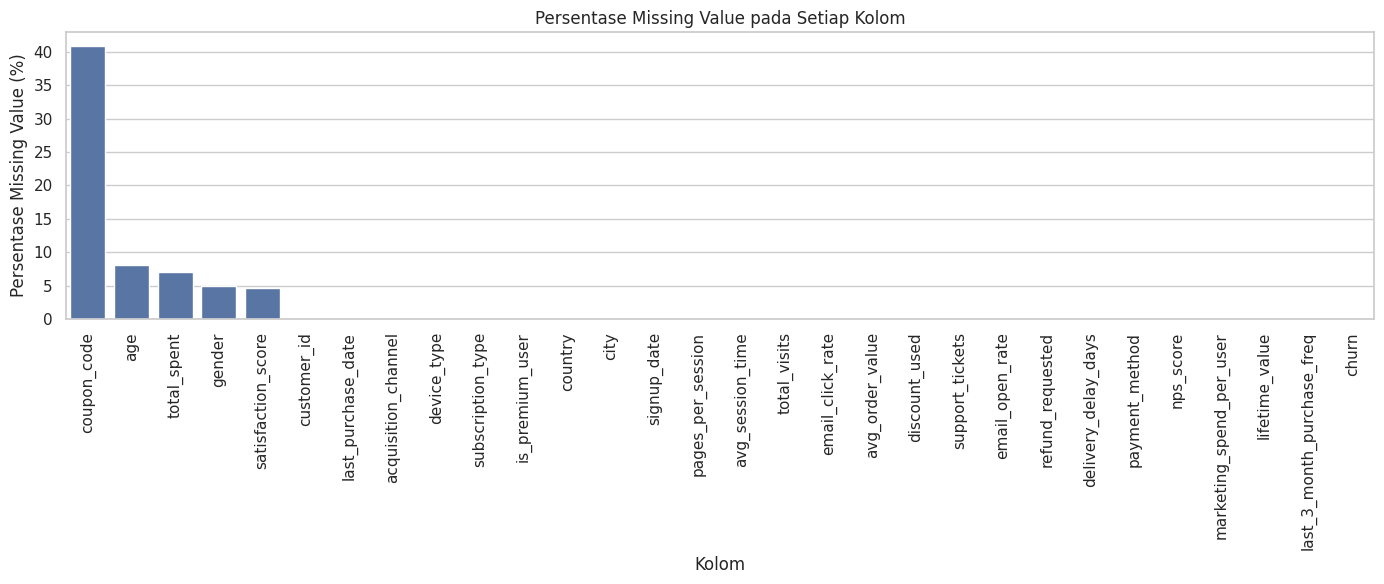

In [ ]:
# ============================================================
# POIN 1.2 - VISUALISASI MISSING VALUE
# ============================================================

plt.figure(figsize=(14, 6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Persentase Missing Value (%)"]
)

plt.xticks(rotation=90)
plt.title("Persentase Missing Value pada Setiap Kolom")
plt.xlabel("Kolom")
plt.ylabel("Persentase Missing Value (%)")
plt.tight_layout()
plt.show()

# Poin Penugasan 1.3 — Distribusi Variabel Target Churn

Bagian ini digunakan untuk mengetahui keseimbangan kelas target `churn`.

- `0` = pelanggan tidak churn
- `1` = pelanggan churn

In [ ]:
# ============================================================
# POIN 1.3 - CEK KOLOM TARGET
# ============================================================

target_col = "churn"

if target_col not in df.columns:
    raise ValueError("Kolom target 'churn' tidak ditemukan. Periksa kembali nama kolom dataset.")

print("Kolom target ditemukan:", target_col)

display(df[target_col].value_counts())
display(df[target_col].value_counts(normalize=True) * 100)

Kolom target ditemukan: churn


,count
churn,
0,12702
1,2298


,proportion
churn,
0,84.68
1,15.32


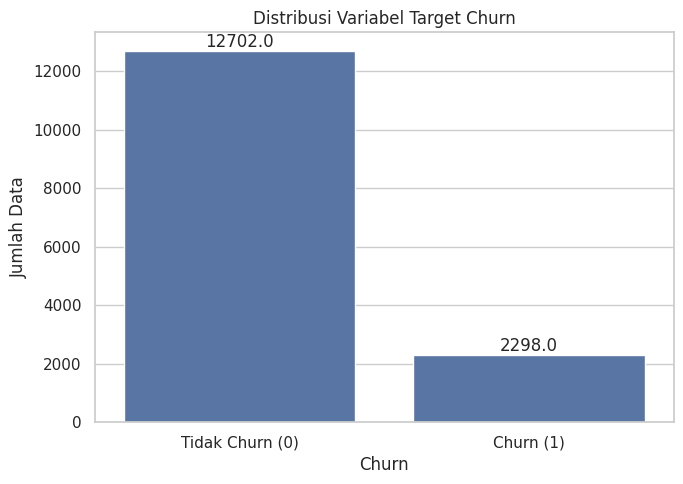

In [ ]:
# ============================================================
# POIN 1.3 - VISUALISASI DISTRIBUSI TARGET CHURN
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=target_col
)

plt.title("Distribusi Variabel Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Data")
plt.xticks([0, 1], ["Tidak Churn (0)", "Churn (1)"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# POIN 1.3 - PERSENTASE DISTRIBUSI TARGET CHURN
# ============================================================

churn_distribution = df[target_col].value_counts().reset_index()
churn_distribution.columns = ["Churn", "Jumlah"]

churn_distribution["Persentase (%)"] = (
    churn_distribution["Jumlah"] / churn_distribution["Jumlah"].sum()
) * 100

display(churn_distribution)

,Churn,Jumlah,Persentase (%)
0,0,12702,84.68
1,1,2298,15.32


# Poin Penugasan 1.4 — Heatmap Korelasi Fitur Numerik

Bagian ini membuat heatmap korelasi antar fitur numerik untuk melihat hubungan antar variabel, terutama variabel yang berpotensi memengaruhi churn pelanggan.

In [ ]:
# ============================================================
# POIN 1.4 - SELEKSI FITUR NUMERIK
# ============================================================

numeric_df = df.select_dtypes(include=["int64", "float64", "int32", "float32"])

print("Jumlah fitur numerik:", numeric_df.shape[1])
display(numeric_df.head())

Jumlah fitur numerik: 20


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,0,0,3,3.0,10,27.56,915.310827,14,0
1,10002,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,5,0,3,3.0,7,15.15,2079.960938,11,0
2,10003,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,1,0,2,5.0,6,13.51,1379.150885,9,0
3,10004,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,0,0,2,4.0,6,25.65,774.652684,7,0
4,10005,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,2,1,4,3.0,1,12.39,87.680409,11,0


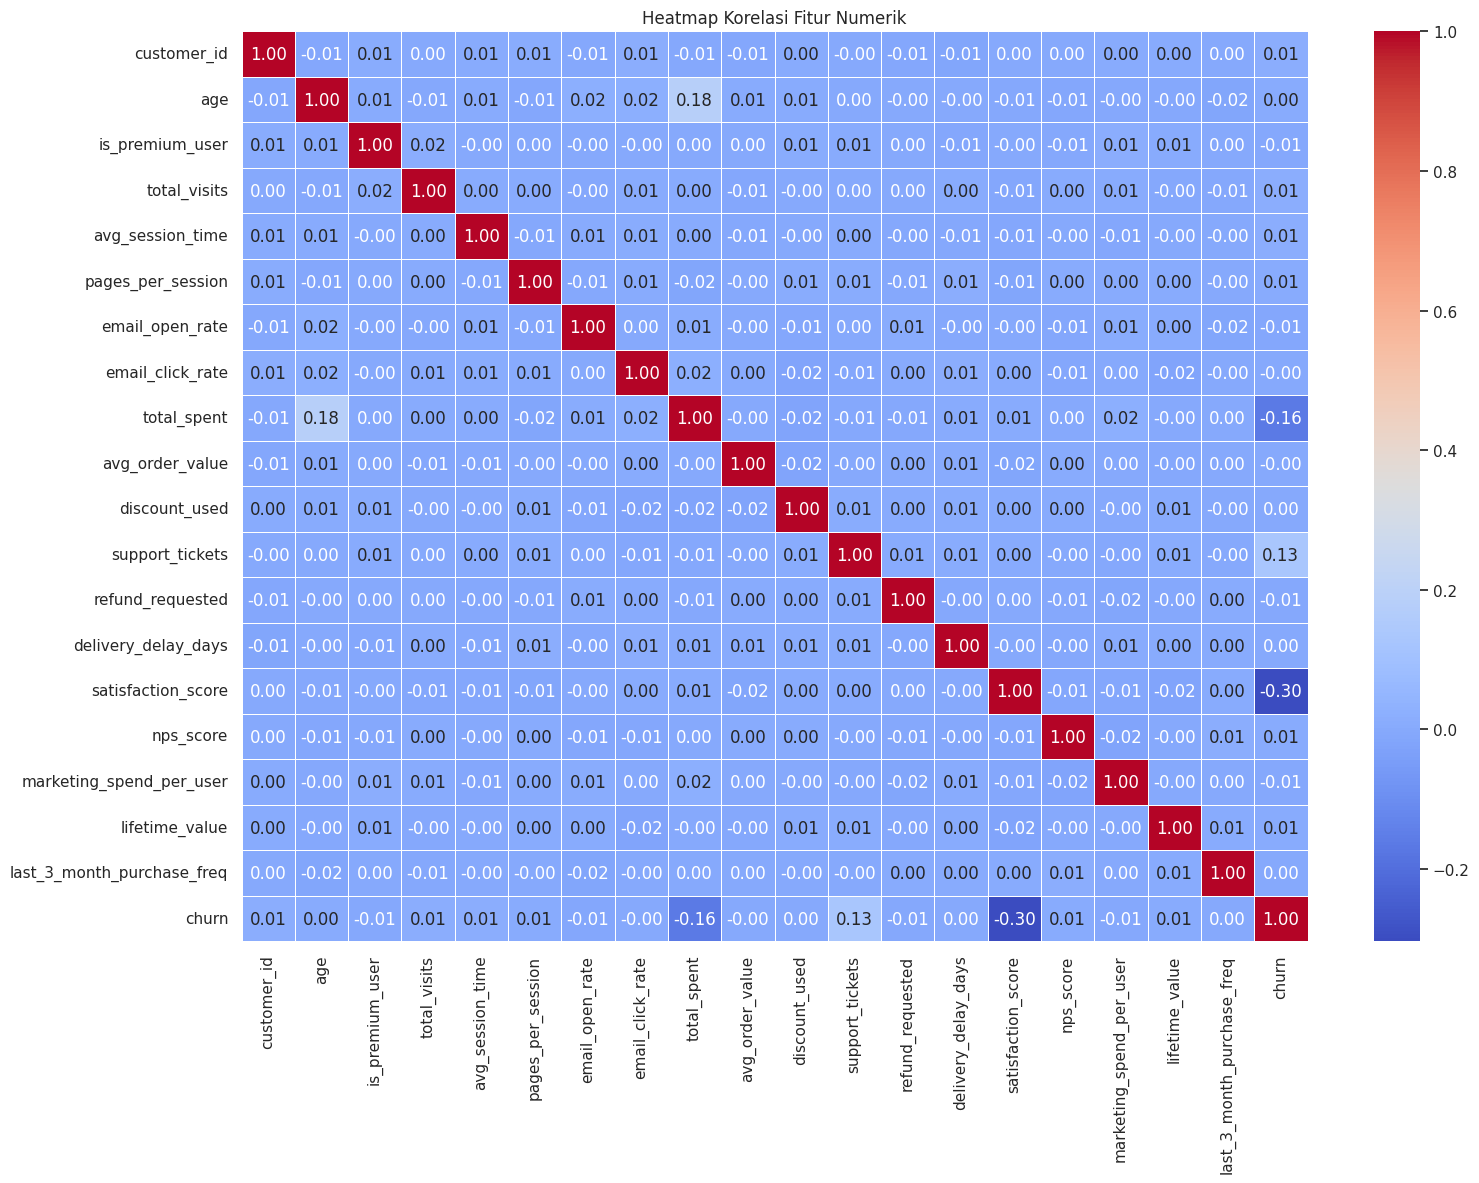

In [ ]:
# ============================================================
# POIN 1.4 - HEATMAP KORELASI FITUR NUMERIK
# ============================================================

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

,Fitur,Korelasi terhadap Churn
0,churn,1.000000
1,support_tickets,0.127910
2,total_visits,0.013212
3,customer_id,0.012208
4,avg_session_time,0.012198
5,lifetime_value,0.006250
6,pages_per_session,0.005871
7,nps_score,0.005749
8,age,0.004506
9,delivery_delay_days,0.001603


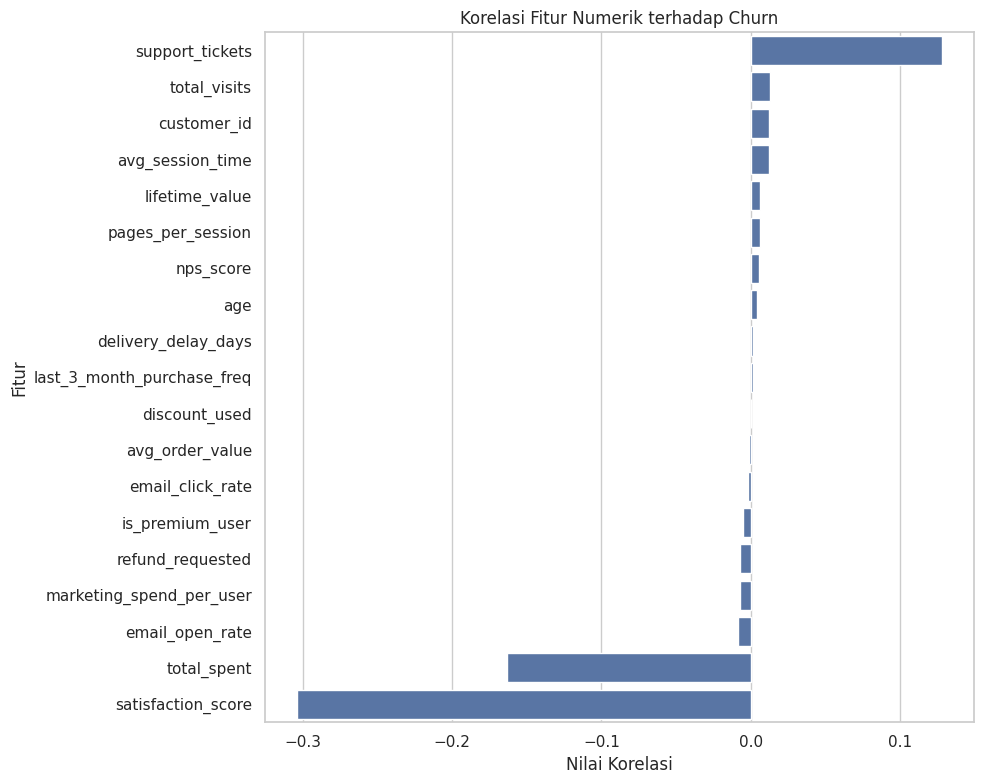

In [ ]:
# ============================================================
# POIN 1.4 - KORELASI FITUR NUMERIK TERHADAP TARGET CHURN
# ============================================================

if target_col in numeric_df.columns:
    churn_corr = corr_matrix[target_col].sort_values(ascending=False)

    churn_corr_df = pd.DataFrame({
        "Fitur": churn_corr.index,
        "Korelasi terhadap Churn": churn_corr.values
    })

    display(churn_corr_df)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=churn_corr_df[churn_corr_df["Fitur"] != target_col],
        x="Korelasi terhadap Churn",
        y="Fitur"
    )

    plt.title("Korelasi Fitur Numerik terhadap Churn")
    plt.xlabel("Nilai Korelasi")
    plt.ylabel("Fitur")
    plt.tight_layout()
    plt.show()

else:
    print("Kolom churn tidak termasuk fitur numerik, korelasi terhadap churn tidak dapat dihitung.")

# Kesimpulan Sementara EDA

Berdasarkan EDA yang telah dilakukan, bagian yang sudah diselesaikan adalah:

1. Menampilkan 5 baris pertama dataset.
2. Menampilkan informasi dataset.
3. Menampilkan statistik deskriptif.
4. Menghitung persentase missing value.
5. Memvisualisasikan missing value dengan diagram batang.
6. Memvisualisasikan distribusi target `churn`.
7. Membuat heatmap korelasi fitur numerik.
8. Melihat korelasi fitur numerik terhadap target `churn`.

Tahap berikutnya setelah EDA adalah masuk ke bagian:
## Poin Penugasan 2 — Direct Modeling